## Macroeconomics Project (EC2B1)

In [612]:
# import modules

import numpy as np
import pandas as pd # import library for data analysis

from get_regression_coefs_general import get_regression_coefs # import our function to get GDP trend

# For plotting
import matplotlib.pyplot as plt
import seaborn as sns # for nicer plots (not essential)
sns.set_theme('talk', style = 'white')


In [613]:
pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


In [614]:
# Load dataset 
#we copied the relevant data for our analysis onto another excel file
excel_file = pd.ExcelFile("/Users/rishika/Rishika - data/LSE/LSE - MSc Economics/Term 2/EC2B1/data_botswana.xlsx")
data1 = excel_file.parse("data") 

In [615]:
# Load the relevant sheet and clean the data
# We dropped the missing values from 1950-60
data = data1[['year', 'rgdpna', 'pop']].dropna()
data

,year,rgdpna,pop
10,1960,439.071747,0.533876
11,1961,472.856598,0.542356
12,1962,509.089539,0.551148
13,1963,530.220337,0.560255
14,1964,560.603821,0.569637
15,1965,534.508423,0.578380
16,1966,572.883301,0.586834
17,1967,683.846619,0.594977
18,1968,781.454956,0.604006
19,1969,779.698242,0.614682


In [616]:
# Cleaning the data

# Import necessary libraries
import pandas as pd
import numpy as np

# Subset relevant columns from the original dataset (data1)
# Keeping only the necessary variables: 'year', 'rgdpna' (real GDP), and 'pop' (population)
# Drop any missing values to ensure clean data
data = data1[['year', 'rgdpna', 'pop']].dropna()

# Using .loc to explicitly select columns (not strictly needed here, but ensures correct column order)
# More about .loc: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html
data = data.loc[:, ("year", "rgdpna", "pop")]

# Compute real GDP per capita (rgdpna_pc) by dividing total GDP by population
data["rgdpna_pc"] = data["rgdpna"] / data["pop"]

# Reset index to ensure a clean sequential index after subsetting
data = data.reset_index(drop=True)

# Define the time range for analysis
ymax = 2019  # Maximum year in the subset
ymin = 1960  # Minimum year in the subset

# Use logical indexing to filter the dataset for the specified years (1960-2019)
# Extract only the real GDP per capita series within the given range
Y = data.loc[np.logical_and(data["year"] <= ymax, data["year"] >= ymin), "rgdpna_pc"]

# Convert GDP per capita values to natural logarithm for further analysis
y = np.log(Y)

# Filter the dataset to keep only years from ymin onwards
data = data[data["year"] <= ymax]

# Print the cleaned dataset to verify the subset
print(data)

# Compute the sample size (T) used for regression
T = len(Y)  # Number of years in the regression sample

# Compute the total number of years in the dataset after ymin (1960)
T_all = data["year"].max() - (ymin - 1)  # Total number of years in the dataset

# Output the total sample size
T_all

    year        rgdpna       pop     rgdpna_pc
0   1960    439.071747  0.533876    822.423051
1   1961    472.856598  0.542356    871.855826
2   1962    509.089539  0.551148    923.690008
3   1963    530.220337  0.560255    946.391241
4   1964    560.603821  0.569637    984.141687
5   1965    534.508423  0.578380    924.147171
6   1966    572.883301  0.586834    976.227255
7   1967    683.846619  0.594977   1149.366373
8   1968    781.454956  0.604006   1293.787018
9   1969    779.698242  0.614682   1268.457050
10  1970    877.892578  0.627715   1398.552812
11  1971   1104.574097  0.646347   1708.949058
12  1972   1395.761353  0.667092   2092.307137
13  1973   1693.103027  0.689912   2454.085488
14  1974   1842.058838  0.714712   2577.344214
15  1975   1997.643677  0.741355   2694.584479
16  1976   2210.340088  0.769979   2870.649833
17  1977   2444.567383  0.800529   3053.689976
18  1978   2729.672363  0.832467   3279.015701
19  1979   3119.644775  0.865075   3606.213074
20  1980   35

60

Compute different trend specifications

Next, we want to compute four different specifications: (i) additive + linear (ii) additive + quadratic
(iii) exponential + linear and (iv) exponential + quadratic. 

We will now run a linear regression `get_regression_coefs(y, x1, x2)` 

# Testing all the models for per capita GDP

/var/folders/_r/b80y3kgx0j9gbhz4kmcpyxz00000gn/T/ipykernel_46058/3639490222.py:30: RuntimeWarning: invalid value encountered in log
  yhat_add_lin = np.log(Yhat_add_lin)


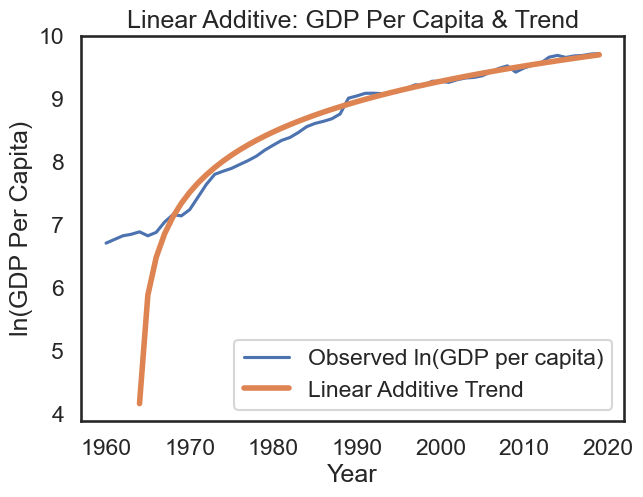

In [619]:
# Additive Linear Model
# Y = β0 + β1*X1 + β2*X2 + ... + βn*Xn + ε

# First regressor x1 is T x 1 vector of ones, second regressor x2 is the vector 1, 2, ..., T
# The dependent variable is per capita GDP in *levels*

import numpy as np
import matplotlib.pyplot as plt

# Initialise empty vectors for regressors
x1 = np.empty(T)  # Intercept term
x2 = np.empty(T)  # Linear term (t)

# Populate the regressor vectors
for t in range(T):
    x1[t] = 1
    x2[t] = t + 1  # Recall Python starts indexing at 0

# Get regression coefficients for linear additive model
a_add_lin, b_add_lin = get_regression_coefs(Y, x1, x2)

# Initialise predicted values Yhat
Yhat_add_lin = np.empty(T_all)

# Compute trend for all years
for t in range(T_all):
    Yhat_add_lin[t] = a_add_lin + b_add_lin * (t + 1)

# Convert into log-units
yhat_add_lin = np.log(Yhat_add_lin)

# Plot results
plt.figure(figsize=(7, 5))
plt.plot(data['year'], np.log(data['rgdpna_pc']), label='Observed ln(GDP per capita)')
plt.plot(data['year'], yhat_add_lin, label='Linear Additive Trend', linewidth=4)

# Labels and title
plt.xlabel("Year")
plt.ylabel("ln(GDP Per Capita)")
plt.title("Linear Additive: GDP Per Capita & Trend")
plt.legend()
plt.show()


/var/folders/_r/b80y3kgx0j9gbhz4kmcpyxz00000gn/T/ipykernel_46058/431531244.py:28: RuntimeWarning: invalid value encountered in log
  yhat_add_quad = np.log(Yhat_add_quad)


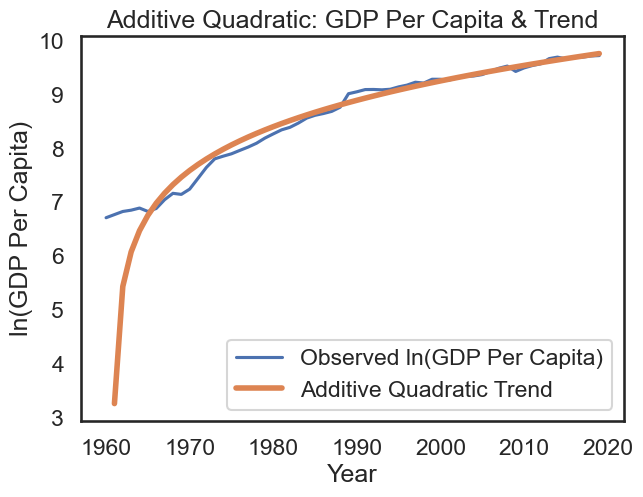

In [620]:
#Additive + Quadratic Model
#Y = β0 + β1*X1 + β2*X2 + β3*(X1^2) + β4*(X2^2) + ε
import numpy as np
import matplotlib.pyplot as plt

# Initialise empty vectors for regressors
x1 = np.empty(T)  # Intercept term
x2 = np.empty(T)  # Linear term (t)
x3 = np.empty(T)  # Quadratic term (t^2)

# Populate the regressor vectors
for t in range(T):
    x1[t] = 1
    x2[t] = t + 1  # Recall Python starts indexing at 0
    x3[t] = (t + 1) ** 2  # Quadratic term

# Get regression coefficients for additive quadratic model
a_add_quad, b_add_quad, c_add_quad = get_regression_coefs(Y, x1, x2, x3)

# Initialise predicted values Yhat
Yhat_add_quad = np.empty(T_all)

# Compute trend for all years
for t in range(T_all):
    Yhat_add_quad[t] = a_add_quad + b_add_quad * (t + 1) + c_add_quad * (t + 1) ** 2

# Convert into log-units
yhat_add_quad = np.log(Yhat_add_quad)

# Plot results
plt.figure(figsize=(7, 5))
plt.plot(data['year'], np.log(data['rgdpna_pc']), label='Observed ln(GDP Per Capita)')
plt.plot(data['year'], yhat_add_quad, label='Additive Quadratic Trend', linewidth=4)

# Labels and title
plt.xlabel("Year")
plt.ylabel("ln(GDP Per Capita)")
plt.title("Additive Quadratic: GDP Per Capita & Trend")
plt.legend()
plt.show()

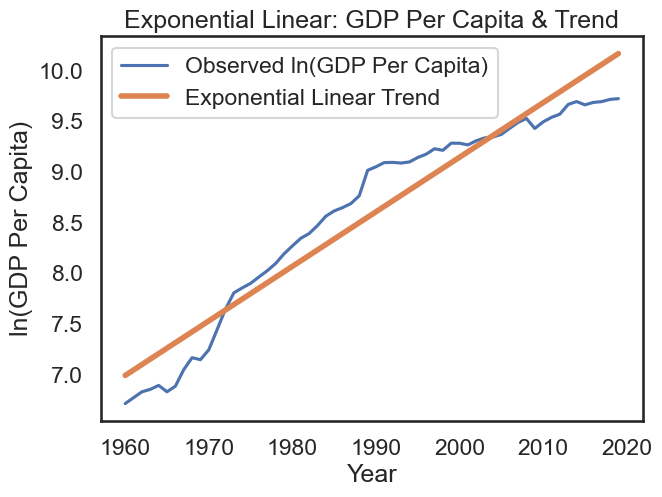

In [621]:
#Exponential + Linear
# logY = β0 + β1*X + β2*X2 +...+ ε
import numpy as np
import matplotlib.pyplot as plt

# Initialise empty vectors for regressors
x1 = np.empty(T)  # Intercept term
x2 = np.empty(T)  # Linear term (t)

# Populate the regressor vectors
for t in range(T):
    x1[t] = 1
    x2[t] = t + 1  # Recall Python starts indexing at 0

# Get regression coefficients for exponential linear model
a_exp_lin, b_exp_lin = get_regression_coefs(np.log(Y), x1, x2)

# Initialise predicted values Yhat
Yhat_exp_lin = np.empty(T_all)

# Compute trend for all years
for t in range(T_all):
    Yhat_exp_lin[t] = np.exp(a_exp_lin + b_exp_lin * (t + 1))

# Convert into log-units
yhat_exp_lin = np.log(Yhat_exp_lin)

# Plot results
plt.figure(figsize=(7, 5))
plt.plot(data['year'], np.log(data['rgdpna_pc']), label='Observed ln(GDP Per Capita)')
plt.plot(data['year'], yhat_exp_lin, label='Exponential Linear Trend', linewidth=4)

# Labels and title
plt.xlabel("Year")
plt.ylabel("ln(GDP Per Capita)")
plt.title("Exponential Linear: GDP Per Capita & Trend")
plt.legend()
plt.show()


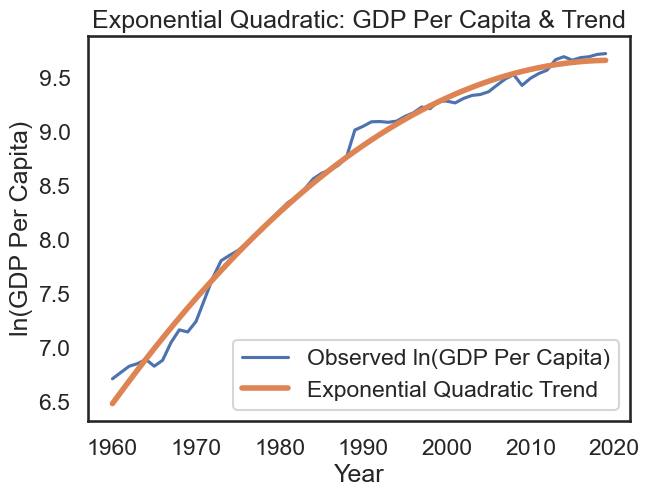

In [622]:
#Exponential + Quadratic
# logY = β0 + β1*X1 + β2*X2^2 + ε
import numpy as np
import matplotlib.pyplot as plt

# Initialise empty vectors for regressors
x1 = np.empty(T)  # Intercept term
x2 = np.empty(T)  # Linear term (t)
x3 = np.empty(T)  # Quadratic term (t^2)

# Populate the regressor vectors
for t in range(T):
    x1[t] = 1
    x2[t] = t + 1  # Recall Python starts indexing at 0
    x3[t] = (t + 1) ** 2  # Quadratic term

# Get regression coefficients for exponential quadratic model
a_exp_quad, b_exp_quad, c_exp_quad = get_regression_coefs(np.log(Y), x1, x2, x3)

# Initialise predicted values Yhat
Yhat_exp_quad = np.empty(T_all)

# Compute trend for all years
for t in range(T_all):
    Yhat_exp_quad[t] = np.exp(a_exp_quad + b_exp_quad * (t + 1) + c_exp_quad * (t + 1) ** 2)

# Convert into log-units
yhat_exp_quad = np.log(Yhat_exp_quad)

# Plot results
plt.figure(figsize=(7, 5))
plt.plot(data['year'], np.log(data['rgdpna_pc']), label='Observed ln(GDP Per Capita)')
plt.plot(data['year'], yhat_exp_quad, label='Exponential Quadratic Trend', linewidth=4)

# Labels and title
plt.xlabel("Year")
plt.ylabel("ln(GDP Per Capita)")
plt.title("Exponential Quadratic: GDP Per Capita & Trend")
plt.legend()
plt.show()


# Testing all the models for GDP

/var/folders/_r/b80y3kgx0j9gbhz4kmcpyxz00000gn/T/ipykernel_46058/2456290160.py:28: RuntimeWarning: invalid value encountered in log
  yhat_add_lin = np.log(Yhat_add_lin)


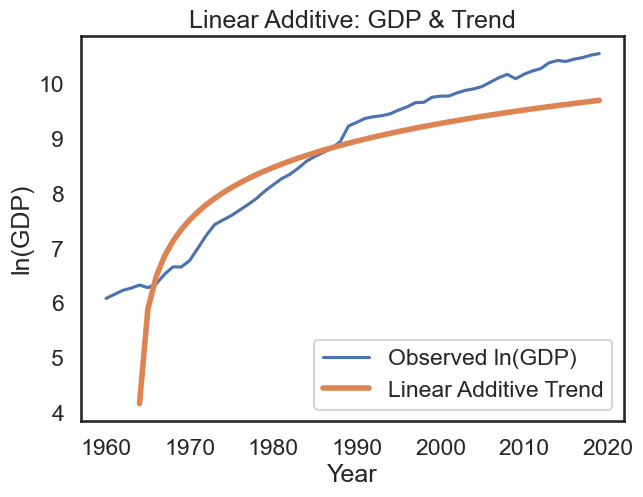

In [624]:
# 3.1) Additive Linear Model
# First regressor x1 is T x 1 vector of ones, second regressor x2 is the vector 1, 2, ..., T
# The dependent variable is per capita GDP in levels

import numpy as np
import matplotlib.pyplot as plt

# Initialise empty vectors for regressors
x1 = np.empty(T)  # Intercept term
x2 = np.empty(T)  # Linear term (t)

# Populate the regressor vectors
for t in range(T):
    x1[t] = 1
    x2[t] = t + 1  # Recall Python starts indexing at 0

# Get regression coefficients for linear additive model
a_add_lin, b_add_lin = get_regression_coefs(Y, x1, x2)

# Initialise predicted values Yhat
Yhat_add_lin = np.empty(T_all)

# Compute trend for all years
for t in range(T_all):
    Yhat_add_lin[t] = a_add_lin + b_add_lin * (t + 1)

# Convert into log-units
yhat_add_lin = np.log(Yhat_add_lin)

# Plot results
plt.figure(figsize=(7, 5))
plt.plot(data['year'], np.log(data['rgdpna']), label='Observed ln(GDP)')
plt.plot(data['year'], yhat_add_lin, label='Linear Additive Trend', linewidth=4)

# Labels and title
plt.xlabel("Year")
plt.ylabel("ln(GDP)")
plt.title("Linear Additive: GDP & Trend")
plt.legend()
plt.show()

/var/folders/_r/b80y3kgx0j9gbhz4kmcpyxz00000gn/T/ipykernel_46058/4069643788.py:28: RuntimeWarning: invalid value encountered in log
  yhat_add_quad = np.log(Yhat_add_quad)


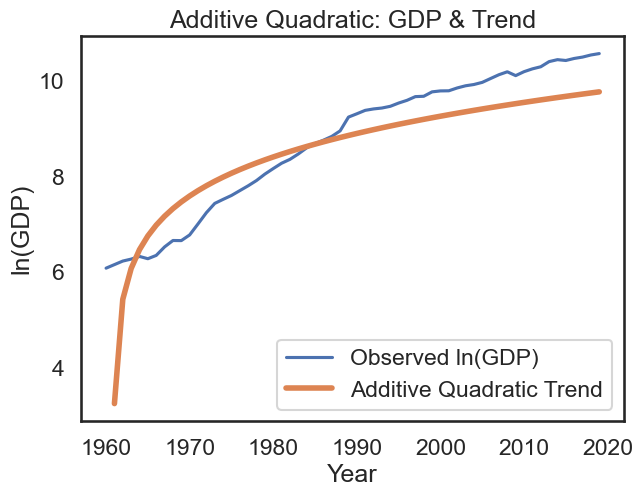

In [625]:
#Additive + Quadratic Model

import numpy as np
import matplotlib.pyplot as plt

# Initialise empty vectors for regressors
x1 = np.empty(T)  # Intercept term
x2 = np.empty(T)  # Linear term (t)
x3 = np.empty(T)  # Quadratic term (t^2)

# Populate the regressor vectors
for t in range(T):
    x1[t] = 1
    x2[t] = t + 1  # Recall Python starts indexing at 0
    x3[t] = (t + 1) ** 2  # Quadratic term

# Get regression coefficients for additive quadratic model
a_add_quad, b_add_quad, c_add_quad = get_regression_coefs(Y, x1, x2, x3)

# Initialise predicted values Yhat
Yhat_add_quad = np.empty(T_all)

# Compute trend for all years
for t in range(T_all):
    Yhat_add_quad[t] = a_add_quad + b_add_quad * (t + 1) + c_add_quad * (t + 1) ** 2

# Convert into log-units
yhat_add_quad = np.log(Yhat_add_quad)

# Plot results
plt.figure(figsize=(7, 5))
plt.plot(data['year'], np.log(data['rgdpna']), label='Observed ln(GDP)')
plt.plot(data['year'], yhat_add_quad, label='Additive Quadratic Trend', linewidth=4)

# Labels and title
plt.xlabel("Year")
plt.ylabel("ln(GDP)")
plt.title("Additive Quadratic: GDP & Trend")
plt.legend()
plt.show()

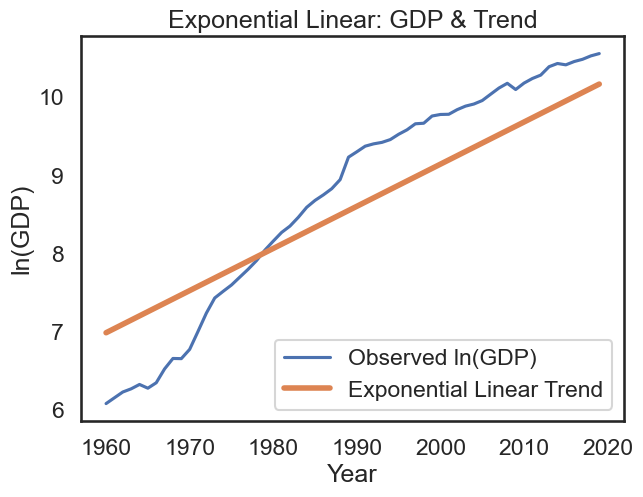

In [626]:
#Exponential + Linear

import numpy as np
import matplotlib.pyplot as plt

# Initialise empty vectors for regressors
x1 = np.empty(T)  # Intercept term
x2 = np.empty(T)  # Linear term (t)

# Populate the regressor vectors
for t in range(T):
    x1[t] = 1
    x2[t] = t + 1  # Recall Python starts indexing at 0

# Get regression coefficients for exponential linear model
a_exp_lin, b_exp_lin = get_regression_coefs(np.log(Y), x1, x2)

# Initialise predicted values Yhat
Yhat_exp_lin = np.empty(T_all)

# Compute trend for all years
for t in range(T_all):
    Yhat_exp_lin[t] = np.exp(a_exp_lin + b_exp_lin * (t + 1))

# Convert into log-units
yhat_exp_lin = np.log(Yhat_exp_lin)

# Plot results
plt.figure(figsize=(7, 5))
plt.plot(data['year'], np.log(data['rgdpna']), label='Observed ln(GDP)')
plt.plot(data['year'], yhat_exp_lin, label='Exponential Linear Trend', linewidth=4)

# Labels and title
plt.xlabel("Year")
plt.ylabel("ln(GDP)")
plt.title("Exponential Linear: GDP & Trend")
plt.legend()
plt.show()


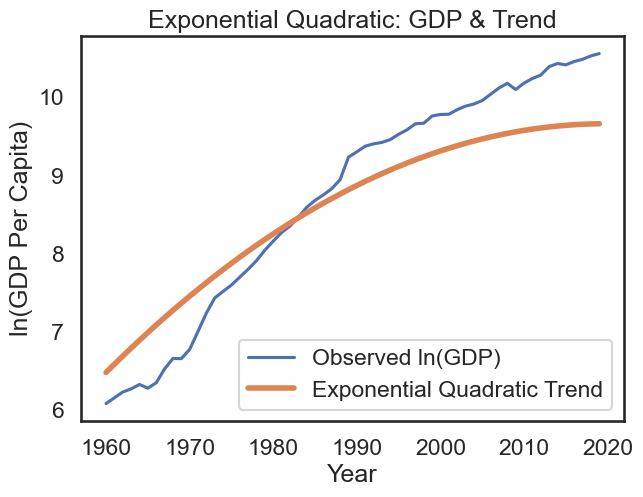

In [627]:
#Exponential + Quadratic

import numpy as np
import matplotlib.pyplot as plt

# Initialise empty vectors for regressors
x1 = np.empty(T)  # Intercept term
x2 = np.empty(T)  # Linear term (t)
x3 = np.empty(T)  # Quadratic term (t^2)

# Populate the regressor vectors
for t in range(T):
    x1[t] = 1
    x2[t] = t + 1  # Recall Python starts indexing at 0
    x3[t] = (t + 1) ** 2  # Quadratic term

# Get regression coefficients for exponential quadratic model
a_exp_quad, b_exp_quad, c_exp_quad = get_regression_coefs(np.log(Y), x1, x2, x3)

# Initialise predicted values Yhat
Yhat_exp_quad = np.empty(T_all)

# Compute trend for all years
for t in range(T_all):
    Yhat_exp_quad[t] = np.exp(a_exp_quad + b_exp_quad * (t + 1) + c_exp_quad * (t + 1) ** 2)

# Convert into log-units
yhat_exp_quad = np.log(Yhat_exp_quad)

# Plot results
plt.figure(figsize=(7, 5))
plt.plot(data['year'], np.log(data['rgdpna']), label='Observed ln(GDP)')
plt.plot(data['year'], yhat_exp_quad, label='Exponential Quadratic Trend', linewidth=4)

# Labels and title
plt.xlabel("Year")
plt.ylabel("ln(GDP Per Capita)")
plt.title("Exponential Quadratic: GDP & Trend")
plt.legend()
plt.show()


In [628]:
# We observe that the exponential quadratic model for the fitted log GPD per capita is the most accurate line of best fit, hence we go ahead with this model for growth accounting for different time periods.

# Growth Accounting over different time periods:

1. **1960-66**: Pre-independence, a period of slow economic growth
2. **1967-80**: Real GDP (rgdpna) increases by 5 times
3. **1981-2000**: Period of rapid growth
4. **2001-19**: Slower growth 

In [630]:
#1.⁠ ⁠1960-66

   year      rgdpna       pop   rgdpna_pc
0  1960  439.071747  0.533876  822.423051
1  1961  472.856598  0.542356  871.855826
2  1962  509.089539  0.551148  923.690008
3  1963  530.220337  0.560255  946.391241
4  1964  560.603821  0.569637  984.141687
5  1965  534.508423  0.578380  924.147171
6  1966  572.883301  0.586834  976.227255


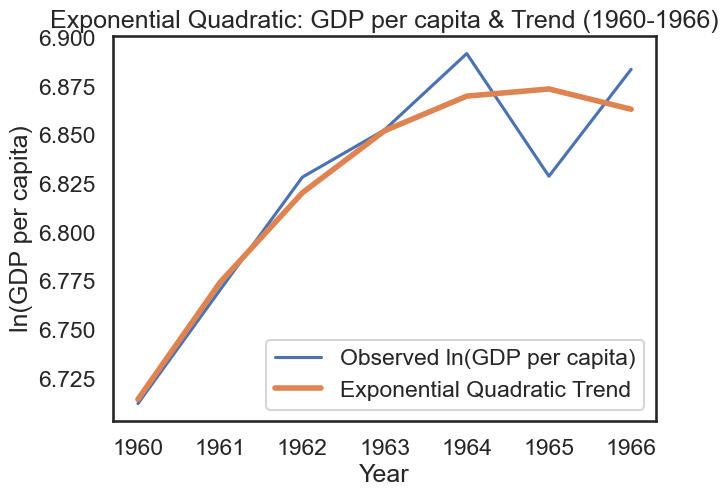

In [631]:
# Subset relevant columns and compute per capita real GDP
data_subset = data1[['year', 'rgdpna', 'pop']].dropna()
data_subset = data_subset.loc[:, ("year", "rgdpna", "pop")]
data_subset["rgdpna_pc"] = data_subset["rgdpna"] / data_subset["pop"]
data_subset = data_subset.reset_index(drop=True)

# Define time period
start_year = 1960
end_year = 1966

# Subset the RGDPNA per capita series
Y_subset = data_subset.loc[np.logical_and(data_subset["year"] <= end_year, data_subset["year"] >= start_year), "rgdpna_pc"]
y_subset = np.log(Y_subset)
data_subset = data_subset[data_subset["year"] <= end_year]  # Keep only years within the range

print(data_subset)

# Compute separate sample sizes for the subsample used for estimation and the whole sample.
T_subset = len(Y_subset)  # Sample size used for regression
T_all_subset = data_subset["year"].max() - (start_year - 1)  # Number of all years in the data after start_year

# Exponential + Quadratic Model
# Initialise empty vectors for regressors
x1_subset = np.empty(T_subset)  # Intercept term
x2_subset = np.empty(T_subset)  # Linear term (t)
x3_subset = np.empty(T_subset)  # Quadratic term (t^2)

# Populate the regressor vectors
for t in range(T_subset):
    x1_subset[t] = 1
    x2_subset[t] = t + 1  # Recall Python starts indexing at 0
    x3_subset[t] = (t + 1) ** 2  # Quadratic term

# Get regression coefficients for exponential quadratic model
a_exp_quad_subset, b_exp_quad_subset, c_exp_quad_subset = get_regression_coefs(np.log(Y_subset), x1_subset, x2_subset, x3_subset)

# Initialise predicted values Yhat
Yhat_exp_quad_subset = np.empty(T_all_subset)

# Compute trend for all years
for t in range(T_all_subset):
    Yhat_exp_quad_subset[t] = np.exp(a_exp_quad_subset + b_exp_quad_subset * (t + 1) + c_exp_quad_subset * (t + 1) ** 2)

# Convert into log-units
yhat_exp_quad_subset = np.log(Yhat_exp_quad_subset)

# Plot results
plt.figure(figsize=(7, 5))
plt.plot(data_subset['year'], np.log(data_subset['rgdpna_pc']), label='Observed ln(GDP per capita)')
plt.plot(data_subset['year'], yhat_exp_quad_subset, label='Exponential Quadratic Trend', linewidth=4)

# Labels and title
plt.xlabel("Year")
plt.ylabel("ln(GDP per capita)")
plt.title("Exponential Quadratic: GDP per capita & Trend (1960-1966)")
plt.legend()
plt.show()


In [632]:
#2.⁠ ⁠⁠1967-80

    year       rgdpna       pop    rgdpna_pc
7   1967   683.846619  0.594977  1149.366373
8   1968   781.454956  0.604006  1293.787018
9   1969   779.698242  0.614682  1268.457050
10  1970   877.892578  0.627715  1398.552812
11  1971  1104.574097  0.646347  1708.949058
12  1972  1395.761353  0.667092  2092.307137
13  1973  1693.103027  0.689912  2454.085488
14  1974  1842.058838  0.714712  2577.344214
15  1975  1997.643677  0.741355  2694.584479
16  1976  2210.340088  0.769979  2870.649833
17  1977  2444.567383  0.800529  3053.689976
18  1978  2729.672363  0.832467  3279.015701
19  1979  3119.644775  0.865075  3606.213074
20  1980  3500.821533  0.897868  3899.038092


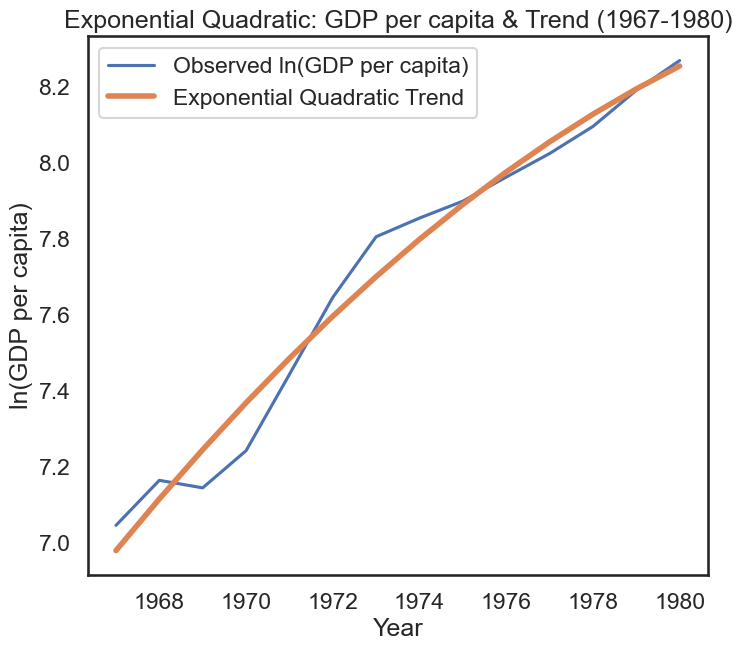

In [633]:
# Subset relevant columns and compute per capita real GDP
data_subset = data1[['year', 'rgdpna', 'pop']].dropna()
data_subset = data_subset.loc[:, ("year", "rgdpna", "pop")]
data_subset["rgdpna_pc"] = data_subset["rgdpna"] / data_subset["pop"]
data_subset = data_subset.reset_index(drop=True)

# Define time period
start_year = 1967
end_year = 1980

# Subset the RGDPNA per capita series
data_subset = data_subset[(data_subset["year"] >= start_year) & (data_subset["year"] <= end_year)]
data_subset['year'] = data_subset['year'].astype(int)
Y_subset = data_subset["rgdpna_pc"]
y_subset = np.log(Y_subset)

print(data_subset)

# Compute sample sizes
T_subset = len(Y_subset)  # Sample size used for regression

# Exponential + Quadratic Model
# Initialise empty vectors for regressors
x1_subset = np.ones(T_subset)  # Intercept term
x2_subset = np.arange(1, T_subset + 1)  # Linear term (t)
x3_subset = x2_subset ** 2  # Quadratic term (t^2)

# Get regression coefficients for exponential quadratic model
a_exp_quad_subset, b_exp_quad_subset, c_exp_quad_subset = get_regression_coefs(y_subset, x1_subset, x2_subset, x3_subset)

# Compute trend only for available years
yhat_exp_quad_subset = a_exp_quad_subset + b_exp_quad_subset * x2_subset + c_exp_quad_subset * x3_subset

# Convert predicted values back to original scale
Yhat_exp_quad_subset = np.exp(yhat_exp_quad_subset)

# Plot results
plt.figure(figsize=(8, 7))
plt.plot(data_subset['year'], y_subset, label='Observed ln(GDP per capita)')
plt.plot(data_subset['year'], np.log(Yhat_exp_quad_subset), label='Exponential Quadratic Trend', linewidth=4)

# Labels and title
plt.xlabel("Year")
plt.ylabel("ln(GDP per capita)")
plt.title("Exponential Quadratic: GDP per capita & Trend (1967-1980)")
plt.legend()
plt.show()

In [634]:
#3. 1981-2000

    year        rgdpna       pop     rgdpna_pc
21  1981   3911.903320  0.930408   4204.503100
22  1982   4241.931641  0.962875   4405.485282
23  1983   4746.649902  0.996130   4765.090804
24  1984   5392.634766  1.031439   5228.263393
25  1985   5890.316895  1.069582   5507.120440
26  1986   6322.506348  1.110943   5691.116779
27  1987   6842.515137  1.154906   5924.737716
28  1988   7678.885742  1.200067   6398.714190
29  1989  10233.868164  1.244484   8223.382674
30  1990  10963.207031  1.286756   8520.035680
31  1991  11777.115234  1.326322   8879.529431
32  1992  12130.553711  1.363554   8896.276723
33  1993  12362.987305  1.399110   8836.322594
34  1994  12811.755859  1.434059   8933.911268
35  1995  13712.474609  1.469174   9333.458535
36  1996  14511.883789  1.504730   9644.177885
37  1997  15676.687500  1.540425  10176.858659
38  1998  15789.872070  1.575824  10020.073352
39  1999  17316.316406  1.610264  10753.712687
40  2000  17660.513672  1.643334  10746.758524


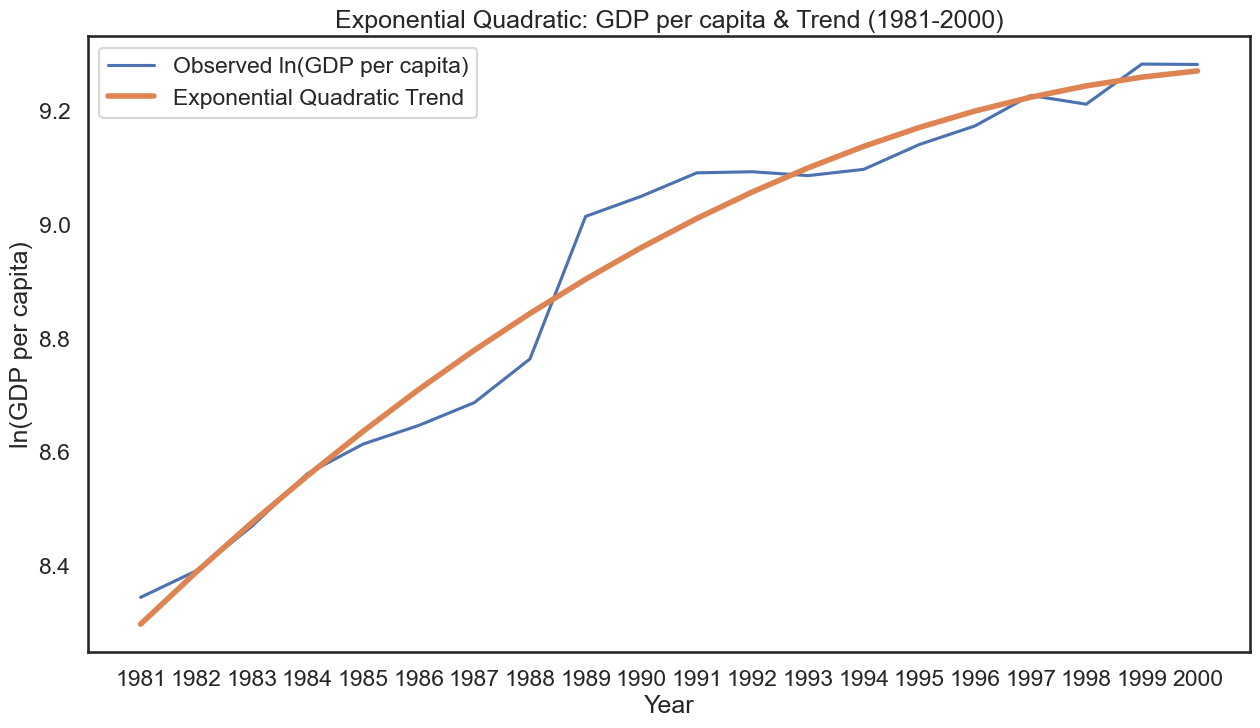

In [635]:
# Subset relevant columns and compute per capita real GDP
data_subset = data1[['year', 'rgdpna', 'pop']].dropna()
data_subset = data_subset.loc[:, ("year", "rgdpna", "pop")]
data_subset["rgdpna_pc"] = data_subset["rgdpna"] / data_subset["pop"]
data_subset = data_subset.reset_index(drop=True)

# Define time period
start_year = 1981
end_year = 2000

# Subset the RGDPNA per capita series
data_subset = data_subset[(data_subset["year"] >= start_year) & (data_subset["year"] <= end_year)]
data_subset['year'] = data_subset['year'].astype(int)  # Ensure year values are integers
Y_subset = data_subset["rgdpna_pc"]
y_subset = np.log(Y_subset)

print(data_subset)

# Compute sample sizes
T_subset = len(Y_subset)  # Sample size used for regression

# Exponential + Quadratic Model
# Initialise empty vectors for regressors
x1_subset = np.ones(T_subset)  # Intercept term
x2_subset = np.arange(1, T_subset + 1)  # Linear term (t)
x3_subset = x2_subset ** 2  # Quadratic term (t^2)

# Get regression coefficients for exponential quadratic model
a_exp_quad_subset, b_exp_quad_subset, c_exp_quad_subset = get_regression_coefs(y_subset, x1_subset, x2_subset, x3_subset)

# Compute trend only for available years
yhat_exp_quad_subset = a_exp_quad_subset + b_exp_quad_subset * x2_subset + c_exp_quad_subset * x3_subset

# Convert predicted values back to original scale
Yhat_exp_quad_subset = np.exp(yhat_exp_quad_subset)

# Plot results
plt.figure(figsize=(15, 8))
plt.plot(data_subset['year'], y_subset, label='Observed ln(GDP per capita)')
plt.plot(data_subset['year'], np.log(Yhat_exp_quad_subset), label='Exponential Quadratic Trend', linewidth=4)

# Format x-axis to show only integer years
plt.xticks(data_subset['year'])

# Labels and title
plt.xlabel("Year")
plt.ylabel("ln(GDP per capita)")
plt.title("Exponential Quadratic: GDP per capita & Trend (1981-2000)")
plt.legend()
plt.show()


In [636]:
#⁠⁠4. 2001-19

    year        rgdpna       pop     rgdpna_pc
41  2001  17704.771484  1.674678  10572.045184
42  2002  18779.361328  1.704642  11016.601332
43  2003  19648.085938  1.734398  11328.475896
44  2004  20179.720703  1.765527  11429.856753
45  2005  21099.220703  1.799078  11727.796518
46  2006  22863.949219  1.835908  12453.755427
47  2007  24756.367188  1.875459  13200.164433
48  2008  26302.501953  1.915639  13730.406383
49  2009  24289.742188  1.953498  12433.973409
50  2010  26369.808594  1.987105  13270.465624
51  2011  27964.759766  2.015403  13875.517584
52  2012  29210.916016  2.039556  14322.193662
53  2013  32524.404297  2.062548  15769.041155
54  2014  33873.957031  2.088618  16218.359236
55  2015  33298.789062  2.120716  15701.672955
56  2016  34731.894531  2.159927  16080.124250
57  2017  35740.503906  2.205080  16208.257254
58  2018  37341.261719  2.254068  16566.164694
59  2019  38448.847656  2.303697  16690.062823


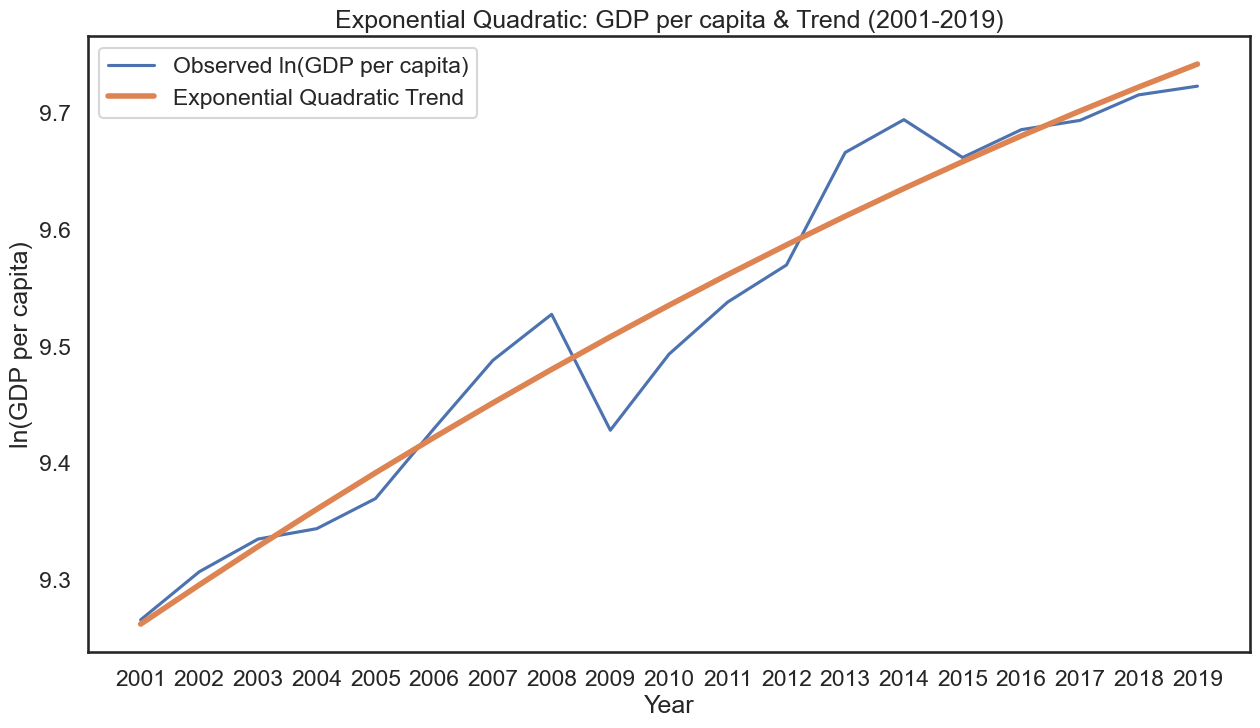

In [637]:
# Subset relevant columns and compute per capita real GDP
data_subset = data1[['year', 'rgdpna', 'pop']].dropna()
data_subset = data_subset.loc[:, ("year", "rgdpna", "pop")]
data_subset["rgdpna_pc"] = data_subset["rgdpna"] / data_subset["pop"]
data_subset = data_subset.reset_index(drop=True)

# Define time period
start_year = 2001
end_year = 2019

# Subset the RGDPNA per capita series
data_subset = data_subset[(data_subset["year"] >= start_year) & (data_subset["year"] <= end_year)]
data_subset['year'] = data_subset['year'].astype(int)  # Ensure year values are integers
Y_subset = data_subset["rgdpna_pc"]
y_subset = np.log(Y_subset)

print(data_subset)

# Compute sample sizes
T_subset = len(Y_subset)  # Sample size used for regression

# Exponential + Quadratic Model
# Initialise empty vectors for regressors
x1_subset = np.ones(T_subset)  # Intercept term
x2_subset = np.arange(1, T_subset + 1)  # Linear term (t)
x3_subset = x2_subset ** 2  # Quadratic term (t^2)

# Get regression coefficients for exponential quadratic model
a_exp_quad_subset, b_exp_quad_subset, c_exp_quad_subset = get_regression_coefs(y_subset, x1_subset, x2_subset, x3_subset)

# Compute trend only for available years
yhat_exp_quad_subset = a_exp_quad_subset + b_exp_quad_subset * x2_subset + c_exp_quad_subset * x3_subset

# Convert predicted values back to original scale
Yhat_exp_quad_subset = np.exp(yhat_exp_quad_subset)

# Plot results
plt.figure(figsize=(15,8))
plt.plot(data_subset['year'], y_subset, label='Observed ln(GDP per capita)')
plt.plot(data_subset['year'], np.log(Yhat_exp_quad_subset), label='Exponential Quadratic Trend', linewidth=4)

# Format x-axis to show only integer years
plt.xticks(data_subset['year'])

# Labels and title
plt.xlabel("Year")
plt.ylabel("ln(GDP per capita)")
plt.title("Exponential Quadratic: GDP per capita & Trend (2001-2019)")
plt.legend()
plt.show()


## To extract a measure of Total Factor Productivity (TFP) using a Cobb-Douglas production function, we assume:

## Cobb-Douglas Production Function:
$$
Y = K^{\alpha} \cdot (A\cdot L)^{(1-\alpha)}
$$

Where:
- **Y** = Real GDP (rgdpna)
- **K** = Capital stock (rnna)
- **L** = Number of employed workers (emp)
- **H** = Human capital index (hc)
- **A** = Total Factor Productivity (TFP)
- **α** = Capital share (default 0.3, but we check robustness for other values)
"""



In [639]:
#Growth Accounting 
data2= data1[["year", "rgdpna", "pop", "emp", "rnna"]].dropna()
data2
#Data presented from hereon starts at 1964 due to missing values of "rtfpna”

,year,rgdpna,pop,emp,rnna
10,1960,439.071747,0.533876,0.172319,1523.394653
11,1961,472.856598,0.542356,0.173054,1542.034302
12,1962,509.089539,0.551148,0.173825,1583.855957
13,1963,530.220337,0.560255,0.174629,1640.541260
14,1964,560.603821,0.569637,0.175450,1732.491577
15,1965,534.508423,0.578380,0.180375,1715.665771
16,1966,572.883301,0.586834,0.181338,1854.192627
17,1967,683.846619,0.594977,0.180531,2058.502441
18,1968,781.454956,0.604006,0.183569,2406.416504
19,1969,779.698242,0.614682,0.189752,2562.336670


In [640]:
# Taking alpha as 0.3
alpha = 0.3

# Compute TFP (A) using the given formula
data2["TMP"] = (data2["rgdpna"]) / ((data2["rnna"] ** alpha) * (data2["emp"] ** (1 - alpha)))
data2["TFP"] = data2["TMP"] ** (1 / (1 - alpha))

# Display the rows of the TFP calculation
print(data2[["year", "TFP"]])

    year           TFP
10  1960   1495.046001
11  1961   1646.394083
12  1962   1800.655890
13  1963   1871.170436
14  1964   1970.134077
15  1965   1797.695933
16  1966   1909.710265
17  1967   2362.088929
18  1968   2628.824139
19  1969   2467.705219
20  1970   2589.937883
21  1971   3106.173588
22  1972   3652.819212
23  1973   4213.257091
24  1974   4372.577368
25  1975   4526.768470
26  1976   4979.304393
27  1977   5465.545092
28  1978   6082.199073
29  1979   6826.876871
30  1980   7409.286475
31  1981   7875.376152
32  1982   8257.408096
33  1983   9376.628204
34  1984  10669.826309
35  1985  11343.212952
36  1986  11787.753999
37  1987  12247.552699
38  1988  13201.248044
39  1989  17719.487508
40  1990  17508.992336
41  1991  17405.467034
42  1992  17332.166798
43  1993  16858.787812
44  1994  16927.065572
45  1995  17875.096156
46  1996  18555.503188
47  1997  19824.584602
48  1998  17886.677566
49  1999  18802.025570
50  2000  18209.894260
51  2001  17423.997188
52  2002  1

In [641]:
# Taking alpha as 0.5 to check if the results are robust to alternative values
alpha = 0.5

# Compute TFP (A) using the given formula
data2["TMP"] = (data2["rgdpna"]) / ((data2["rnna"] ** alpha) * (data2["emp"] ** (1 - alpha)))
data2["TFP"] = data2["TMP"] ** (1 / (1 - alpha))

# Display the rows of the TFP calculation
print(data2[["year", "TFP"]])

    year           TFP
10  1960    734.386828
11  1961    837.881511
12  1962    941.372033
13  1963    981.318636
14  1964   1033.920548
15  1965    923.209276
16  1966    976.086335
17  1967   1258.388414
18  1968   1382.412401
19  1969   1250.347212
20  1970   1256.908821
21  1971   1474.738448
22  1972   1712.391402
23  1973   1949.449586
24  1974   1985.198872
25  1975   2054.558484
26  1976   2318.201666
27  1977   2618.427364
28  1978   3008.949456
29  1979   3484.107232
30  1980   3804.900358
31  1981   4041.381962
32  1982   4205.157908
33  1983   4899.710551
34  1984   5829.587890
35  1985   6289.999015
36  1986   6569.613090
37  1987   6920.178171
38  1988   7605.951339
39  1989  11017.583009
40  1990  10480.618541
41  1991  10221.522523
42  1992   9879.570387
43  1993   9346.602970
44  1994   9268.108872
45  1995   9845.247758
46  1996  10254.387112
47  1997  11036.608134
48  1998   9620.397820
49  1999  10224.396784
50  2000   9646.034045
51  2001   8915.881783
52  2002   

In [642]:
# Taking alpha as 0.2 to check if the results are robust to alternative values
alpha = 0.2

# Compute TFP (A) using the given formula
data2["TMP"] = (data2["rgdpna"]) / ((data2["rnna"] ** alpha) * (data2["emp"] ** (1 - alpha)))
data2["TFP"] = data2["TMP"] ** (1 / (1 - alpha))

# Display the rows of the TFP calculation
print(data2[["year", "TFP"]])

    year           TFP
10  1960   1866.949539
11  1961   2033.321455
12  1962   2205.222546
13  1963   2289.328572
14  1964   2409.896969
15  1965   2213.903872
16  1966   2355.346184
17  1967   2875.803601
18  1968   3213.569944
19  1969   3051.847706
20  1970   3246.458382
21  1971   3920.331774
22  1972   4628.588101
23  1973   5360.602078
24  1974   5596.341601
25  1975   5794.254767
26  1976   6323.013853
27  1977   6878.698571
28  1978   7578.354623
29  1979   8423.893529
30  1980   9124.818404
31  1981   9700.977471
32  1982  10195.897218
33  1983  11485.053714
34  1984  12888.271970
35  1985  13638.380622
36  1986  14150.509787
37  1987  14639.561873
38  1988  15683.633823
39  1989  20556.073640
40  1990  20554.615259
41  1991  20555.419031
42  1992  20660.400447
43  1993  20271.237707
44  1994  20432.839489
45  1995  21537.370518
46  1996  22333.725920
47  1997  23806.428366
48  1998  21711.877523
49  1999  22744.783587
50  2000  22209.792289
51  2001  21482.268145
52  2002  2

## Growth Accounting
We next compute the contribution of each factor to the total growth rate of output.

$$
\begin{aligned}
\text{contr\_K} &= \alpha \cdot \frac{g_K}{g_Y} \\
\text{contr\_L} &= (1 - \alpha) \cdot \frac{g_L}{g_Y} \\
\text{contr\_A} &= (1 - \alpha) \cdot \frac{g_A}{g_Y}
\end{aligned}
$$

In [644]:
data = data2.copy() 

In [645]:
#define variables for growth accounting
Y=data2["rgdpna"]
K=data2["rnna"]
L=data2["emp"]
A=data2["TFP"]

In [646]:
# Define alpha 
alpha = 0.3

# Compute growth rates (log differences)
data["g_Y"] = data["rgdpna"].pct_change()
data["g_K"] = data["rnna"].pct_change()
data["g_L"] = data["emp"].pct_change()

# Compute TFP using given formula
data["TMP"] = (data["rgdpna"]) / ((data["rnna"] ** alpha) * (data["emp"] ** (1 - alpha)))
data["TFP"] = data["TMP"] ** (1 / (1 - alpha))

# Compute TFP growth rate
data["g_A"] = data["TFP"].pct_change()

# Compute contributions to GDP growth
data["contr_K"] = alpha * (data["g_K"] / data["g_Y"])
data["contr_L"] = (1 - alpha) * (data["g_L"] / data["g_Y"])
data["contr_A"] = (1 - alpha) * (data["g_A"] / data["g_Y"])

# Converting the years into time intervals 
data["year"] = data["year"].astype(str) + "-" + (data["year"] + 1).astype(str).str[-2:]

# Display the results
print(data[["year", "g_Y", "contr_K", "contr_L", "contr_A"]].dropna())

       year       g_Y   contr_K    contr_L    contr_A
11  1961-62  0.076946  0.047705   0.038805   0.920945
12  1962-63  0.076626  0.106183   0.040669   0.855950
13  1963-64  0.041507  0.258675   0.078007   0.660426
14  1964-65  0.057304  0.293431   0.057466   0.646069
15  1965-66 -0.046549  0.062592  -0.422108   1.316218
16  1966-67  0.071795  0.337388   0.052066   0.607523
17  1967-68  0.193693  0.170664  -0.016091   0.856090
18  1968-69  0.142734  0.355233   0.082536   0.553801
19  1969-70 -0.002248 -8.646805 -10.488040  19.084728
20  1970-71  0.125939  0.510179   0.214924   0.275316
21  1971-72  0.258211  0.357199   0.086709   0.540359
22  1972-73  0.263619  0.332311   0.170830   0.467305
23  1973-74  0.213032  0.339554   0.136069   0.504142
24  1974-75  0.087978  0.425057   0.266912   0.300869
25  1975-76  0.084462  0.302116   0.391817   0.292251
26  1976-77  0.106474  0.164202   0.166316   0.657235
27  1977-78  0.105969  0.147105   0.194401   0.645063
28  1978-79  0.116628  0.143

In [647]:
# Compute the average contributions
average_contributions = data[["g_Y", "contr_K", "contr_L", "contr_A"]].mean()

# Display results
print("Average Contributions")
print(f"Average GDP Growth (g_Y): {average_contributions['g_Y']:.4f}")
print(f"Average Contribution of Capital (contr_K): {average_contributions['contr_K']:.4f}")
print(f"Average Contribution of Labor (contr_L): {average_contributions['contr_L']:.4f}")
print(f"Average Contribution of TFP (contr_A): {average_contributions['contr_A']:.4f}")

Average Contributions
Average GDP Growth (g_Y): 0.0809
Average Contribution of Capital (contr_K): 0.3275
Average Contribution of Labor (contr_L): 0.2880
Average Contribution of TFP (contr_A): 0.3852


In [648]:
# Define alpha 
alpha = 0.3

# Define function to compute contributions for our chosen time intervals
def compute_contributions(start, end):
    K_contrib = alpha * np.log(K[end] / K[start]) / np.log(Y[end] / Y[start])
    L_contrib = (1 - alpha) * np.log(L[end] / L[start]) / np.log(Y[end] / Y[start])
    A_contrib = (1 - alpha) * np.log(A[end] / A[start]) / np.log(Y[end] / Y[start])
    Y_growth = np.log(Y[end] / Y[start])
    
    return K_contrib, L_contrib, A_contrib, Y_growth

# Define the year indices 
year_indices = {
    "1960-66": (year.index[year == 1960][0], year.index[year == 1966][0]),
    "1967-80": (year.index[year == 1967][0], year.index[year == 1980][0]),
    "1981-2000": (year.index[year == 1981][0], year.index[year == 2000][0]),
    "2001-19": (year.index[year == 2001][0], year.index[year == 2019][0])}


print("Year \t\t K contrib \t L contrib \t A contrib \t Y growth")
print("------- \t --------- \t --------- \t --------- \t --------")

# Compute and print results for each time interval
for period, (start, end) in year_indices.items():
    K_contrib, L_contrib, A_contrib, Y_growth = compute_contributions(start, end)
    print(
        f"{period} \t {K_contrib:.4f} \t {L_contrib:.4f} \t {A_contrib:.4f} \t {Y_growth:.4f}")


Year 		 K contrib 	 L contrib 	 A contrib 	 Y growth
------- 	 --------- 	 --------- 	 --------- 	 --------
1960-66 	 0.2216 	 0.1342 	 0.6115 	 0.2660
1967-80 	 0.3118 	 0.1982 	 0.4950 	 1.6330
1981-2000 	 0.2889 	 0.3218 	 0.3847 	 1.5073
2001-19 	 0.4559 	 0.3655 	 0.2436 	 0.7755


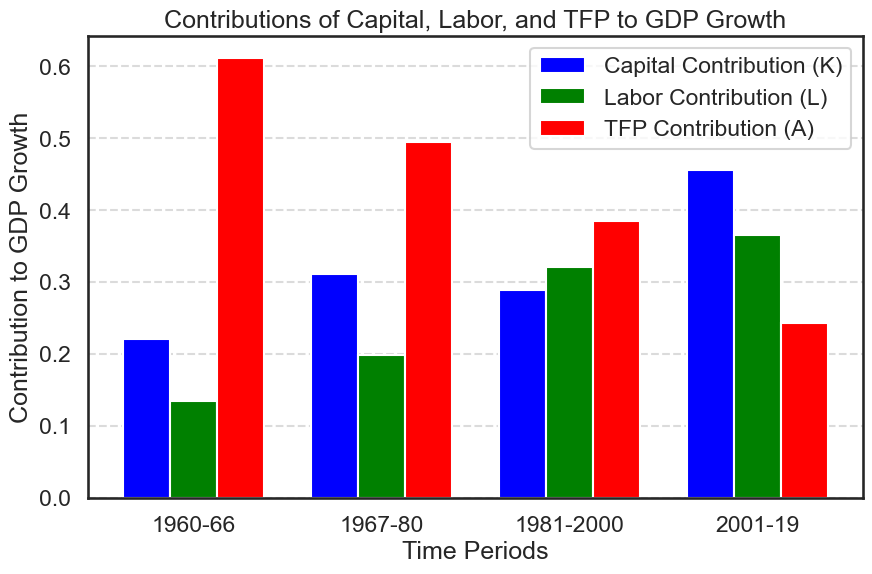

In [649]:
import numpy as np
import matplotlib.pyplot as plt

# Define alpha 
alpha = 0.3

# Define function to compute contributions for our chosen time intervals
def compute_contributions(start, end):
    K_contrib = alpha * np.log(K[end] / K[start]) / np.log(Y[end] / Y[start])
    L_contrib = (1 - alpha) * np.log(L[end] / L[start]) / np.log(Y[end] / Y[start])
    A_contrib = (1 - alpha) * np.log(A[end] / A[start]) / np.log(Y[end] / Y[start])
    return K_contrib, L_contrib, A_contrib

# Define the year indices
year_indices = {
    "1960-66": (year.index[year == 1960][0], year.index[year == 1966][0]),
    "1967-80": (year.index[year == 1967][0], year.index[year == 1980][0]),
    "1981-2000": (year.index[year == 1981][0], year.index[year == 2000][0]),
    "2001-19": (year.index[year == 2001][0], year.index[year == 2019][0])
}

# Store results in lists for plotting
time_periods = list(year_indices.keys())
K_contributions, L_contributions, A_contributions = [], [], []

# Compute contributions for each time interval
for period, (start, end) in year_indices.items():
    K_contrib, L_contrib, A_contrib = compute_contributions(start, end)
    K_contributions.append(K_contrib)
    L_contributions.append(L_contrib)
    A_contributions.append(A_contrib)

# Plotting contributions
bar_width = 0.25
x = np.arange(len(time_periods))

plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, K_contributions, bar_width, label="Capital Contribution (K)", color="blue")
plt.bar(x, L_contributions, bar_width, label="Labor Contribution (L)", color="green")
plt.bar(x + bar_width, A_contributions, bar_width, label="TFP Contribution (A)", color="red")

# Formatting the plot
plt.xlabel("Time Periods")
plt.ylabel("Contribution to GDP Growth")
plt.title("Contributions of Capital, Labor, and TFP to GDP Growth")
plt.xticks(x, time_periods)  # Label x-axis with time periods
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()

## Constructing a series for labour productivity

In [651]:
# Ensure that "rgdpna" (real GDP) and "emp" (employment) exist in data2
data2["labour_productivity"] = data2["rgdpna"] / data2["emp"]

# Display the first few rows
print(data2[["year", "rgdpna", "emp", "labour_productivity"]])

# Save results to a new CSV file (optional)
data2.to_csv("labor_productivity_series.csv", index=False)

    year        rgdpna       emp  labour_productivity
10  1960    439.071747  0.172319          2548.014021
11  1961    472.856598  0.173054          2732.418320
12  1962    509.089539  0.173825          2928.753371
13  1963    530.220337  0.174629          3036.273035
14  1964    560.603821  0.175450          3195.230883
15  1965    534.508423  0.180375          2963.318233
16  1966    572.883301  0.181338          3159.198537
17  1967    683.846619  0.180531          3787.977527
18  1968    781.454956  0.183569          4257.008023
19  1969    779.698242  0.189752          4109.039033
20  1970    877.892578  0.197089          4454.290407
21  1971   1104.574097  0.203393          5430.736889
22  1972   1395.761353  0.216478          6447.584360
23  1973   1693.103027  0.225443          7510.129474
24  1974   1842.058838  0.233005          7905.650572
25  1975   1997.643677  0.244021          8186.355737
26  1976   2210.340088  0.250194          8834.495894
27  1977   2444.567383  0.25

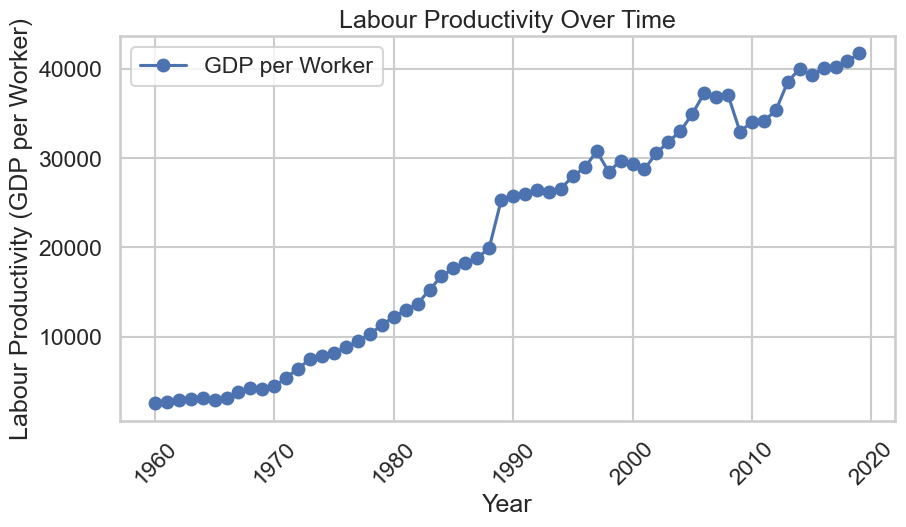

In [652]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for better visuals
sns.set_style("whitegrid")

# Plot labor productivity over time
plt.figure(figsize=(10, 5))
plt.plot(data2["year"], data2["labour_productivity"], marker="o", linestyle="-", color="b", label="GDP per Worker")

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Labour Productivity (GDP per Worker)")
plt.title("Labour Productivity Over Time")
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Show the plot
plt.show()